In [1]:
# Installazione librerie
!pip install rdflib pgmpy kagglehub

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Nome del file dentro il dataset di Kaggle
file_path = "Medicine_Details.csv"

# Caricamento diretto da Kaggle in un DataFrame pandas
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "singhnavjot2062001/11000-medicine-details",
    file_path,
)

print(f"Dataset caricato con successo: {df.shape[0]} record, {df.shape[1]} colonne.")
df.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 14.5 MB/s eta 0:00:00


100%|██████████| 763k/763k [00:00<00:00, 95.5MB/s]

Extracting zip of Medicine_Details.csv...
Dataset caricato con successo: 11825 record, 9 colonne.


,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21


In [2]:
# 1.Parsing semantico dell'area terapeutica (Uses)
def extract_therapeutic_area(uses_str):
    u = str(uses_str).lower()
    if any(k in u for k in ['diabet', 'sugar', 'glyc', 'thyroid', 'insulin']):
        return 'Endocrine_Metabolic'
    elif any(k in u for k in ['hypertension', 'blood pressure', 'heart', 'cardiac', 'angina', 'cholesterol', 'stroke', 'arrhythmia']):
        return 'Cardiovascular'
    elif any(k in u for k in ['bacterial', 'antibiotic', 'fungal', 'infection', 'viral', 'parasit', 'candida', 'malaria']):
        return 'Infectious_Diseases'
    elif any(k in u for k in ['pain', 'fever', 'arthrit', 'inflammat', 'headache', 'migraine', 'analgesic']):
        return 'Pain_and_Inflammation'
    elif any(k in u for k in ['reflux', 'peptic', 'ulcer', 'gastric', 'acidity', 'stomach', 'bowel', 'diarrhea']):
        return 'Gastrointestinal'
    elif any(k in u for k in ['cough', 'asthma', 'copd', 'respiratory', 'bronch', 'allergy', 'sneezing', 'allergic']):
        return 'Respiratory_and_Allergy'
    elif any(k in u for k in ['schizophrenia', 'depression', 'anxiety', 'psych', 'mania', 'epilep', 'seizure', 'parkinson', 'neuropathic']):
        return 'Neuro_Psychiatry'
    elif any(k in u for k in ['cancer', 'tumor', 'leukemia', 'carcinoma', 'chemotherapy']):
        return 'Oncology'
    elif any(k in u for k in ['acne', 'skin', 'eczema', 'psoriasis', 'dermat']):
        return 'Dermatology'
    elif any(k in u for k in ['eye', 'dry eyes', 'glaucoma', 'ocular']):
        return 'Ophthalmology'
    else:
        return 'General_Medicine'

# 2.Complessità farmacologica (Composition)
def extract_drug_complexity(comp_str):
    return 'Multi_Component' if '+' in str(comp_str) else 'Mono_Component'

# 3.Toxicity tiering (Side_effects)
def extract_toxicity(side_str):
    s = str(side_str).strip()
    if not s or s.lower() in ['none', 'no side effects']:
        return 'Low_Toxicity', 0
    tokens = re.findall(r'[A-Z][a-z]+', s)
    count = len(tokens)
    if count <= 3:
        return 'Low_Toxicity', count
    elif count <= 7:
        return 'Moderate_Toxicity', count
    else:
        return 'High_Toxicity', count

# 4.Target obiettivo: High_Therapeutic_Success (Binario)
def define_target(row):
    return 1 if (row['Excellent Review %'] >= 38 and row['Poor Review %'] <= 28) else 0

df['Therapeutic_Area'] = df['Uses'].apply(extract_therapeutic_area)
df['Drug_Complexity'] = df['Composition'].apply(extract_drug_complexity)
df[['Toxicity_Tier', 'Side_Effects_Count']] = df['Side_effects'].apply(lambda x: pd.Series(extract_toxicity(x)))
df['Target_Success'] = df.apply(define_target, axis=1)

print("Distribuzione Target Success:")
print(df['Target_Success'].value_counts(normalize=True) * 100)

Distribuzione Target Success:
Target_Success
0    59.306554
1    40.693446
Name: proportion, dtype: float64


ANALISI QUALITATIVA E STRUTTURALE DEL CORPUS CLINICO
-> Dimensione totale del campione:              11,825 record
-> Valori nulli rilevati (su tutte le colonne): 0 (Integrità 100%)
-> Record interamente duplicati (lotti):        84 (~0.71%)
-> Specialità farmaceutiche univoche:           11,498
-> Produttori farmaceutici distinti:           759


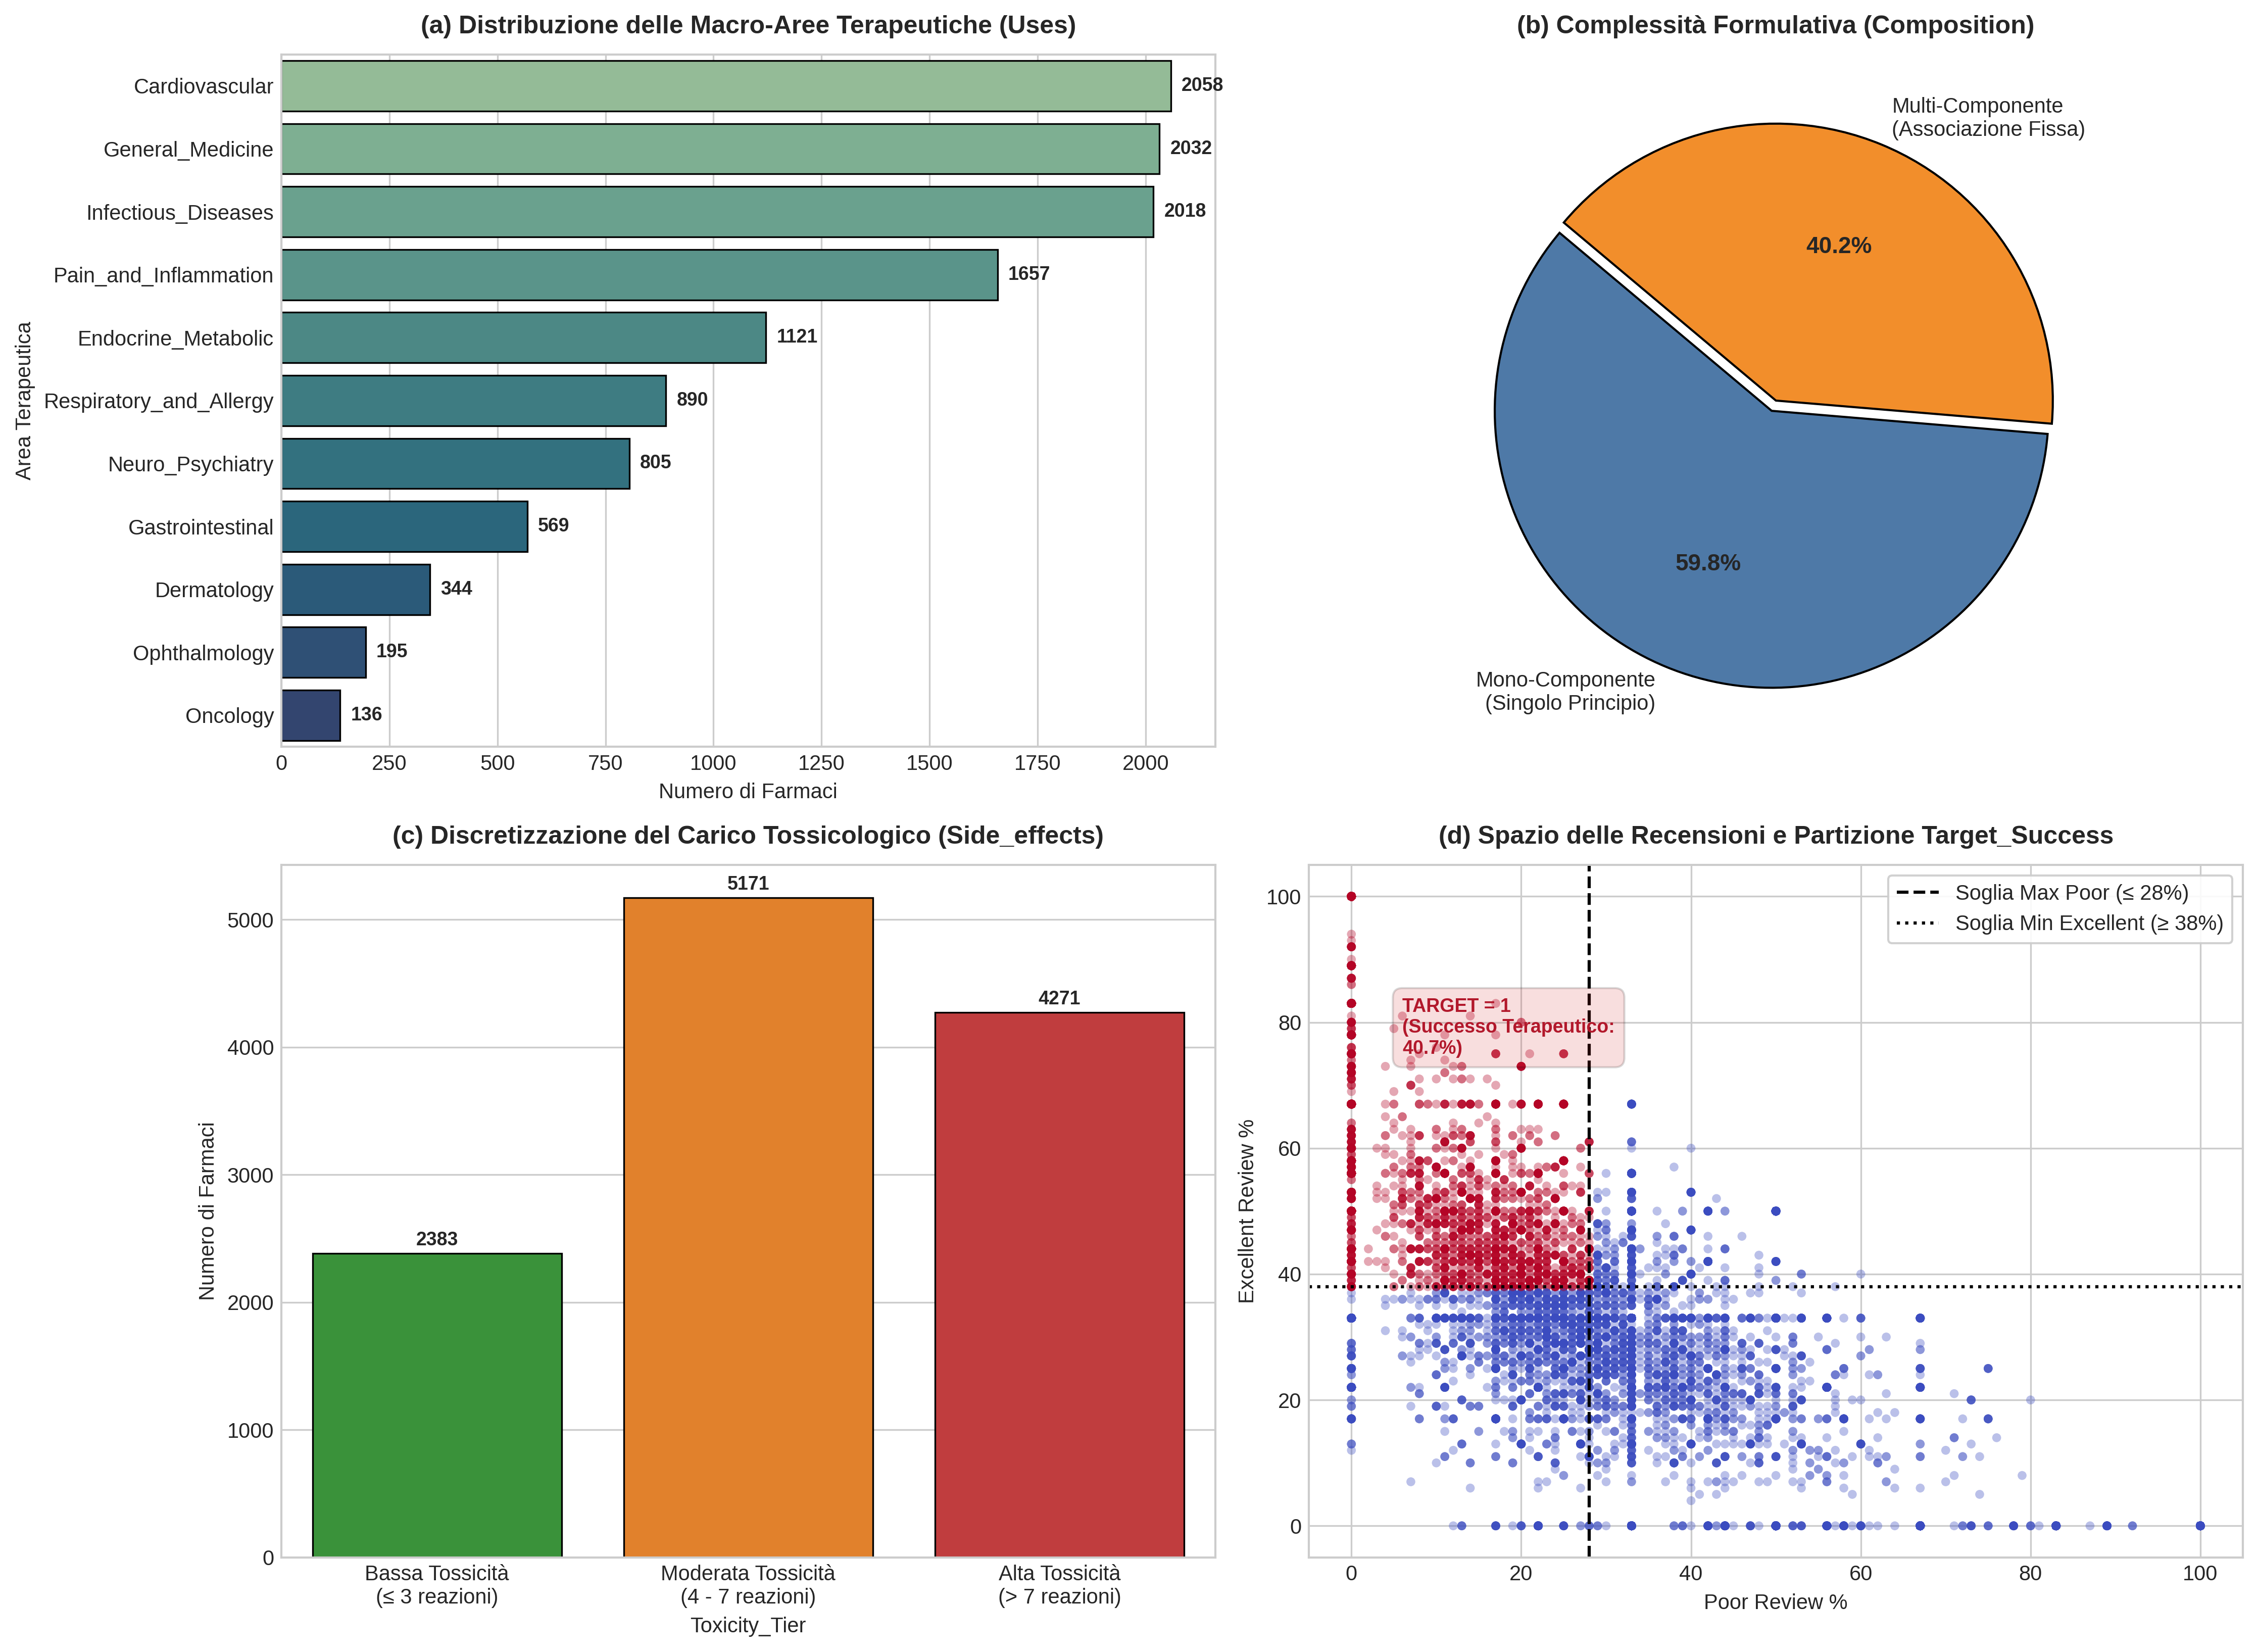

In [3]:
# ANALISI ESPLORATIVA, INTEGRITÀ DATI E VISUALIZZAZIONE DEL PRE-PROCESSING
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# 1. Controllo di integrità e unicità
null_counts = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()
unique_drugs = df['Medicine Name'].nunique()
unique_manufacturers = df['Manufacturer'].nunique()

print("ANALISI QUALITATIVA E STRUTTURALE DEL CORPUS CLINICO")
print(f"-> Dimensione totale del campione:              {len(df):,} record")
print(f"-> Valori nulli rilevati (su tutte le colonne): {null_counts} (Integrità 100%)")
print(f"-> Record interamente duplicati (lotti):        {duplicate_rows} (~{duplicate_rows/len(df)*100:.2f}%)")
print(f"-> Specialità farmaceutiche univoche:           {unique_drugs:,}")
print(f"-> Produttori farmaceutici distinti:           {unique_manufacturers}")
print("="*80)

# 2. Pipeline di visualizzazione
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axs = plt.subplots(2, 2, figsize=(15, 11), dpi=300)

# Quadrante (a): Distribuzione delle macro-aree terapeutiche (Uses)
area_counts = df['Therapeutic_Area'].value_counts()
sns.barplot(x=area_counts.values, y=area_counts.index, ax=axs[0, 0], palette='crest', edgecolor='black', linewidth=0.8)
axs[0, 0].set_title('(a) Distribuzione delle Macro-Aree Terapeutiche (Uses)', fontsize=12, fontweight='bold', pad=10)
axs[0, 0].set_xlabel('Numero di Farmaci', fontsize=10)
axs[0, 0].set_ylabel('Area Terapeutica', fontsize=10)
for i, v in enumerate(area_counts.values):
    axs[0, 0].text(v + 25, i, f"{v}", va='center', fontsize=9, fontweight='semibold')

# Quadrante (b): Complessità formulativa (Composition)
comp_counts = df['Drug_Complexity'].value_counts()
colors = ['#4e79a7', '#f28e2b']
wedges, texts, autotexts = axs[0, 1].pie(
    comp_counts,
    labels=['Mono-Componente\n(Singolo Principio)', 'Multi-Componente\n(Associazione Fissa)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.04, 0),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axs[0, 1].set_title('(b) Complessità Formulativa (Composition)', fontsize=12, fontweight='bold', pad=10)

# Quadrante (c): Discretizzazione del carico tossicologico (Side_effects)
tox_order = ['Low_Toxicity', 'Moderate_Toxicity', 'High_Toxicity']
tox_counts = df['Toxicity_Tier'].value_counts().reindex(tox_order)
sns.barplot(x=tox_counts.index, y=tox_counts.values, ax=axs[1, 0], palette=['#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black', linewidth=0.8)
axs[1, 0].set_title('(c) Discretizzazione del Carico Tossicologico (Side_effects)', fontsize=12, fontweight='bold', pad=10)
axs[1, 0].set_ylabel('Numero di Farmaci', fontsize=10)
axs[1, 0].set_xticklabels(['Bassa Tossicità\n(≤ 3 reazioni)', 'Moderata Tossicità\n(4 - 7 reazioni)', 'Alta Tossicità\n(> 7 reazioni)'], fontsize=10)
for i, v in enumerate(tox_counts.values):
    axs[1, 0].text(i, v + 65, f"{v}", ha='center', fontsize=9, fontweight='semibold')

# Quadrante (d): Spazio delle recensioni e partizione logica Target_Success
axs[1, 1].scatter(
    df['Poor Review %'],
    df['Excellent Review %'],
    c=df['Target_Success'],
    cmap='coolwarm',
    alpha=0.35,
    s=18,
    edgecolors='none'
)
axs[1, 1].axvline(x=28, color='black', linestyle='--', linewidth=1.5, label='Soglia Max Poor (≤ 28%)')
axs[1, 1].axhline(y=38, color='black', linestyle=':', linewidth=1.5, label='Soglia Min Excellent (≥ 38%)')
axs[1, 1].set_title('(d) Spazio delle Recensioni e Partizione Target_Success', fontsize=12, fontweight='bold', pad=10)
axs[1, 1].set_xlabel('Poor Review %', fontsize=10)
axs[1, 1].set_ylabel('Excellent Review %', fontsize=10)
axs[1, 1].legend(loc='upper right', frameon=True, framealpha=0.9, facecolor='white')

# Annotazione regione target positivo
axs[1, 1].text(6, 75, 'TARGET = 1\n(Successo Terapeutico:\n40.7%)',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#d62728', alpha=0.15),
               fontsize=9, fontweight='bold', color='#b2182b')

plt.tight_layout()
plt.savefig('eda_preprocessing_overview.png', bbox_inches='tight')
plt.show()

In [4]:
import rdflib
from rdflib import Graph, Literal, RDF, RDFS, OWL, Namespace, URIRef
from rdflib.namespace import XSD
from google.colab import files

g = Graph()
PHARMA = Namespace("http://www.semanticweb.org/uniba/icon/pharma#")
g.bind("pharma", PHARMA)
g.bind("owl", OWL)
g.bind("rdfs", RDFS)

# TBox: Classi principali e gerarchia
classes = ["TherapeuticArea", "DrugFormulation", "ClinicalRiskProfile",
           "CardiovascularArea", "OncologyArea", "NeuroPsychiatryArea", "GeneralArea",
           "MonoComponent", "MultiComponent", "LowRisk", "ModerateRisk", "HighRisk"]

for c in classes:
    g.add((PHARMA[c], RDF.type, OWL.Class))

g.add((PHARMA.CardiovascularArea, RDFS.subClassOf, PHARMA.TherapeuticArea))
g.add((PHARMA.OncologyArea, RDFS.subClassOf, PHARMA.TherapeuticArea))
g.add((PHARMA.NeuroPsychiatryArea, RDFS.subClassOf, PHARMA.TherapeuticArea))
g.add((PHARMA.MonoComponent, RDFS.subClassOf, PHARMA.DrugFormulation))
g.add((PHARMA.MultiComponent, RDFS.subClassOf, PHARMA.DrugFormulation))

# Assioma di disgiunzione
g.add((PHARMA.MonoComponent, OWL.disjointWith, PHARMA.MultiComponent))

# Proprietà
g.add((PHARMA.hasRiskProfile, RDF.type, OWL.ObjectProperty))
g.add((PHARMA.recommendedSafetyCheck, RDF.type, OWL.DatatypeProperty))

# ABox: Conoscenza di fondo per le aree
guidelines = {
    "Cardiovascular": (PHARMA.ModerateRisk, "Blood_Pressure_Monitoring"),
    "Oncology": (PHARMA.HighRisk, "Intensive_Clinical_Vigilance"),
    "Neuro_Psychiatry": (PHARMA.HighRisk, "Neurological_SideEffects_Monitoring"),
    "General_Medicine": (PHARMA.LowRisk, "Standard_Vigilance")
}

for area, (risk_node, check_desc) in guidelines.items():
    area_uri = PHARMA[f"Area_{area}"]
    g.add((area_uri, RDF.type, PHARMA.TherapeuticArea))
    g.add((area_uri, PHARMA.hasRiskProfile, risk_node))
    g.add((area_uri, PHARMA.recommendedSafetyCheck, Literal(check_desc, datatype=XSD.string)))

# Serializzazione e download automatico del file .rdf
g.serialize(destination="pharma_ontology.rdf", format="xml")
print("Ontologia serializzata con successo in formato RDF/XML.")
files.download("pharma_ontology.rdf")

# Interrogazione semantica con SPARQL
sparql_query = """
PREFIX pharma: <http://www.semanticweb.org/uniba/icon/pharma#>
SELECT ?area ?risk ?check
WHERE {
    ?area pharma:hasRiskProfile ?risk .
    ?area pharma:recommendedSafetyCheck ?check .
}
"""
qres = g.query(sparql_query)
kb_guidelines = {}
for row in qres:
    area_name = str(row.area).split('#Area_')[-1]
    risk_level = str(row.risk).split('#')[-1]
    kb_guidelines[area_name] = {"risk": risk_level, "check": str(row.check)}

print("Regole ontologiche caricate in cache semantica:")
print(kb_guidelines)

Ontologia serializzata con successo in formato RDF/XML.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Regole ontologiche caricate in cache semantica:
{'Cardiovascular': {'risk': 'ModerateRisk', 'check': 'Blood_Pressure_Monitoring'}, 'Oncology': {'risk': 'HighRisk', 'check': 'Intensive_Clinical_Vigilance'}, 'Neuro_Psychiatry': {'risk': 'HighRisk', 'check': 'Neurological_SideEffects_Monitoring'}, 'General_Medicine': {'risk': 'LowRisk', 'check': 'Standard_Vigilance'}}


In [5]:
# Motore a regole deduttive (Forward Chaining)
def apply_expert_rules(row):
    area = row['Therapeutic_Area']
    comp = row['Drug_Complexity']
    tox = row['Toxicity_Tier']

    # Integrazione delle linee guida ontologiche
    is_high_risk_area = kb_guidelines.get(area, {}).get('risk') == 'HighRisk'

    # Regola 1: Alto rischio clinico
    if is_high_risk_area or (comp == 'Multi_Component' and tox == 'High_Toxicity'):
        risk = 'High_Risk'
    # Regola 2: Rischio moderato
    elif comp == 'Multi_Component' or tox in ['Moderate_Toxicity', 'High_Toxicity'] or area in ['Cardiovascular', 'Endocrine_Metabolic']:
        risk = 'Moderate_Risk'
    # Regola 3: Basso rischio
    else:
        risk = 'Low_Risk'

    # Feature semantica: viabilità del trattamento
    if risk == 'Low_Risk' and tox == 'Low_Toxicity':
        viability = 'High_Viability'
    elif risk == 'High_Risk':
        viability = 'Guarded_Viability'
    else:
        viability = 'Standard_Viability'

    return pd.Series([risk, viability], index=['Clinical_Risk', 'Treatment_Viability'])

df[['Clinical_Risk', 'Treatment_Viability']] = df.apply(apply_expert_rules, axis=1)

# Esportazione dataset arricchito
df.to_csv('pharma_enriched.csv', index=False)
print("Dataset arricchito salvato: pharma_enriched.csv")

Dataset arricchito salvato: pharma_enriched.csv


In [6]:
df = pd.read_csv("pharma_enriched.csv")
df.head()

,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %,Therapeutic_Area,Drug_Complexity,Toxicity_Tier,Side_Effects_Count,Target_Success,Clinical_Risk,Treatment_Viability
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22,Oncology,Mono_Component,High_Toxicity,9,0,High_Risk,Guarded_Viability
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18,Infectious_Diseases,Multi_Component,Moderate_Toxicity,4,1,Moderate_Risk,Standard_Viability
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21,Infectious_Diseases,Mono_Component,Low_Toxicity,3,1,Low_Risk,High_Viability
3,Ascoril LS Syrup,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...,Treatment of Cough with mucus,Nausea Vomiting Diarrhea Upset stomach Stomach...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glenmark Pharmaceuticals Ltd,24,41,35,Respiratory_and_Allergy,Multi_Component,High_Toxicity,14,0,High_Risk,Guarded_Viability
4,Aciloc 150 Tablet,Ranitidine (150mg),Treatment of Gastroesophageal reflux disease (...,Headache Diarrhea Gastrointestinal disturbance,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Cadila Pharmaceuticals Ltd,34,37,29,Gastrointestinal,Mono_Component,Low_Toxicity,3,0,Low_Risk,High_Viability


In [7]:
import pandas as pd

# 1. Conteggi assoluti e percentuali normalizzate per riga
ct_abs = pd.crosstab(df['Clinical_Risk'], df['Target_Success'])
ct_pct = pd.crosstab(df['Clinical_Risk'], df['Target_Success'], normalize='index') * 100
total_counts = df['Clinical_Risk'].value_counts()

# 2. Costruzione della tabella riassuntiva
summary_table = pd.DataFrame({
    'Livello Rischio Clinico': ['Basso Rischio (Low)', 'Rischio Moderato (Moderate)', 'Alto Rischio (High)'],
    'Insuccesso (Target = 0)': [
        f"{ct_abs.loc['Low_Risk', 0]:,} ({ct_pct.loc['Low_Risk', 0]:.2f}%)",
        f"{ct_abs.loc['Moderate_Risk', 0]:,} ({ct_pct.loc['Moderate_Risk', 0]:.2f}%)",
        f"{ct_abs.loc['High_Risk', 0]:,} ({ct_pct.loc['High_Risk', 0]:.2f}%)"
    ],
    'Successo (Target = 1)': [
        f"{ct_abs.loc['Low_Risk', 1]:,} ({ct_pct.loc['Low_Risk', 1]:.2f}%)",
        f"{ct_abs.loc['Moderate_Risk', 1]:,} ({ct_pct.loc['Moderate_Risk', 1]:.2f}%)",
        f"{ct_abs.loc['High_Risk', 1]:,} ({ct_pct.loc['High_Risk', 1]:.2f}%)"
    ],
    'Totale Farmaci': [
        f"{total_counts['Low_Risk']:,}",
        f"{total_counts['Moderate_Risk']:,}",
        f"{total_counts['High_Risk']:,}"
    ]
})

print(summary_table.to_string(index=False))




    Livello Rischio Clinico Insuccesso (Target = 0) Successo (Target = 1) Totale Farmaci
        Basso Rischio (Low)            863 (65.08%)          463 (34.92%)          1,326
Rischio Moderato (Moderate)          4,787 (60.68%)        3,102 (39.32%)          7,889
        Alto Rischio (High)          1,363 (52.22%)        1,247 (47.78%)          2,610


Test Chi-Quadro: chi2 = 78.77, p-value = 7.86e-18, V di Cramér = 0.0816


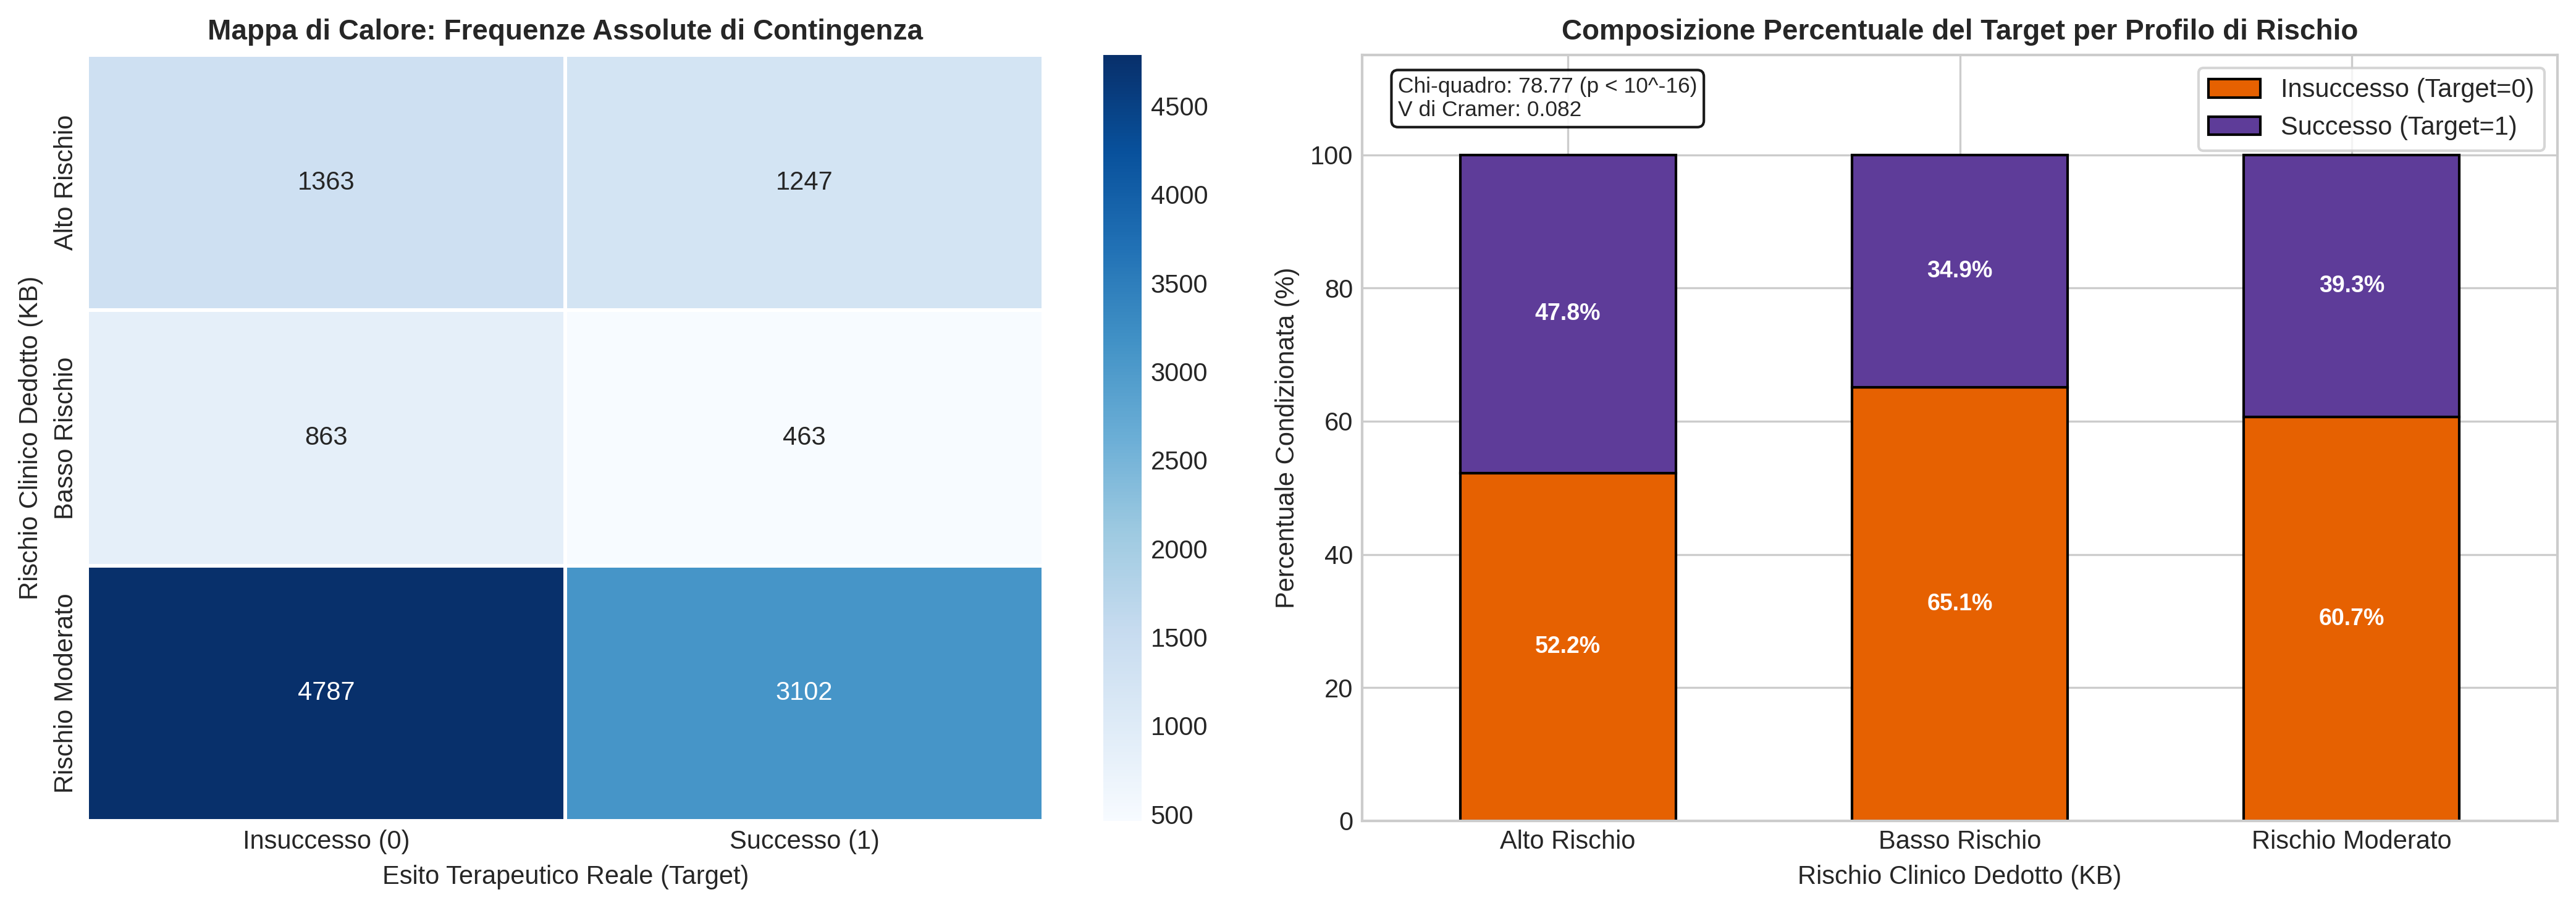

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Calcolo del test Chi-quadro di indipendenza
ct_raw = pd.crosstab(df['Clinical_Risk'], df['Target_Success'])
chi2, p_val, dof, _ = stats.chi2_contingency(ct_raw)
n_obs = ct_raw.sum().sum()
cramers_v = np.sqrt((chi2 / n_obs) / (min(ct_raw.shape) - 1))

print(f"Test Chi-Quadro: chi2 = {chi2:.2f}, p-value = {p_val:.2e}, V di Cramér = {cramers_v:.4f}")

# 2. Pipeline grafica
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Pannello 1: Mappa di calore dei valori assoluti
ct_matrix = pd.crosstab(df['Clinical_Risk'], df['Target_Success'])
ct_matrix.index = ['Alto Rischio', 'Basso Rischio', 'Rischio Moderato']
ct_matrix.columns = ['Insuccesso (0)', 'Successo (1)']

sns.heatmap(ct_matrix, annot=True, fmt="d", cmap='Blues', cbar=True, ax=ax1, linewidths=1, linecolor='white')
ax1.set_title('Mappa di Calore: Frequenze Assolute di Contingenza', fontsize=11, fontweight='bold')
ax1.set_ylabel('Rischio Clinico Dedotto (KB)', fontsize=10)
ax1.set_xlabel('Esito Terapeutico Reale (Target)', fontsize=10)

# Pannello 2: Grafico a barre con percentuali normalizzate per riga
ct_norm = pd.crosstab(df['Clinical_Risk'], df['Target_Success'], normalize='index') * 100
ct_norm.index = ['Alto Rischio', 'Basso Rischio', 'Rischio Moderato']
ct_norm.columns = ['Insuccesso (Target=0)', 'Successo (Target=1)']

ct_norm.plot(kind='bar', stacked=True, color=['#e66101', '#5e3c99'], ax=ax2, edgecolor='black', width=0.55)
ax2.set_title('Composizione Percentuale del Target per Profilo di Rischio', fontsize=11, fontweight='bold')
ax2.set_ylabel('Percentuale Condizionata (%)', fontsize=10)
ax2.set_xlabel('Rischio Clinico Dedotto (KB)', fontsize=10)
ax2.set_ylim(0, 115)
ax2.legend(loc='upper right', frameon=True, facecolor='white')
plt.setp(ax2.get_xticklabels(), rotation=0)

# Annotazioni percentuali all'interno delle barre
for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5:
        ax2.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Box con metriche inferenziali
ax2.text(0.03, 0.92, f"Chi-quadro: {chi2:.2f} (p < 10^-16)\nV di Cramer: {cramers_v:.3f}",
         transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9), fontsize=8.5)

plt.tight_layout()
plt.savefig('heatmap_contingency_risk.png', bbox_inches='tight')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Feature Setup
df_raw = pd.DataFrame({
    'Side_Effects_Count': df['Side_Effects_Count'],
    'Name_Length': df['Medicine Name'].apply(len),
    'Composition_Length': df['Composition'].apply(len),
    'Uses_Length': df['Uses'].apply(len)
})

df_kb = pd.concat([
    df_raw,
    pd.get_dummies(df[['Therapeutic_Area', 'Drug_Complexity', 'Toxicity_Tier', 'Clinical_Risk', 'Treatment_Viability']], drop_first=True)
], axis=1)

y = df['Target_Success'].values

models = {
    'K-NN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    'Logistic Regression': (LogisticRegression(max_iter=500), {'C': [0.1, 1.0, 10.0]}),
    'Decision Tree': (DecisionTreeClassifier(), {'max_depth': [3, 5, 10]}),
    'Random Forest': (RandomForestClassifier(), {'n_estimators': [50, 100], 'max_depth': [5, 10, None]})
}

metrics_summary = {m: {'raw_acc': [], 'kb_acc': [], 'raw_f1': [], 'kb_f1': []} for m in models}

print("Esecuzione su 10 Run indipendenti...")
indices = np.arange(len(df))

for run in range(10):
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42 + run, stratify=y)

    # Scaling selettivo
    scaler_raw = StandardScaler()
    X_raw_train = scaler_raw.fit_transform(df_raw.iloc[train_idx])
    X_raw_test = scaler_raw.transform(df_raw.iloc[test_idx])

    scaler_kb = StandardScaler()
    X_kb_train = scaler_kb.fit_transform(df_kb.iloc[train_idx])
    X_kb_test = scaler_kb.transform(df_kb.iloc[test_idx])

    y_train, y_test = y[train_idx], y[test_idx]

    for name, (clf, params) in models.items():
        # Scenario Raw
        grid_raw = GridSearchCV(clf, params, cv=3, scoring='f1', n_jobs=-1)
        grid_raw.fit(X_raw_train, y_train)
        pred_raw = grid_raw.predict(X_raw_test)
        metrics_summary[name]['raw_acc'].append(accuracy_score(y_test, pred_raw))
        metrics_summary[name]['raw_f1'].append(f1_score(y_test, pred_raw))

        # Scenario +KB
        grid_kb = GridSearchCV(clf, params, cv=3, scoring='f1', n_jobs=-1)
        grid_kb.fit(X_kb_train, y_train)
        pred_kb = grid_kb.predict(X_kb_test)
        metrics_summary[name]['kb_acc'].append(accuracy_score(y_test, pred_kb))
        metrics_summary[name]['kb_f1'].append(f1_score(y_test, pred_kb))

# Creazione tabella di riepilogo
table_rows = []
for name in models:
    table_rows.append({
        'Modello': name,
        'Accuratezza (Grezzo)': f"{np.mean(metrics_summary[name]['raw_acc'])*100:.2f}% ± {np.std(metrics_summary[name]['raw_acc'])*100:.2f}",
        'Accuratezza (+KB)': f"{np.mean(metrics_summary[name]['kb_acc'])*100:.2f}% ± {np.std(metrics_summary[name]['kb_acc'])*100:.2f}",
        'F1-Score (Grezzo)': f"{np.mean(metrics_summary[name]['raw_f1'])*100:.2f}% ± {np.std(metrics_summary[name]['raw_f1'])*100:.2f}",
        'F1-Score (+KB)': f"{np.mean(metrics_summary[name]['kb_f1'])*100:.2f}% ± {np.std(metrics_summary[name]['kb_f1'])*100:.2f}"
    })

comparison_df = pd.DataFrame(table_rows)
print("TABELLA COMPARATIVA 10 RUN CON MEDIA E DEVIAZIONE STANDARD")
print("\n")
print(comparison_df.to_string(index=False))

Esecuzione su 10 Run indipendenti...
TABELLA COMPARATIVA 10 RUN CON MEDIA E DEVIAZIONE STANDARD


            Modello Accuratezza (Grezzo) Accuratezza (+KB) F1-Score (Grezzo) F1-Score (+KB)
               K-NN        57.63% ± 0.80     59.03% ± 0.54     45.51% ± 1.39  46.61% ± 0.68
Logistic Regression        58.78% ± 0.34     62.05% ± 0.69      5.45% ± 0.64  40.12% ± 0.84
      Decision Tree        61.12% ± 0.65     61.80% ± 0.87     41.08% ± 1.35  41.22% ± 1.54
      Random Forest        58.61% ± 1.06     59.05% ± 1.14     45.90% ± 1.58  46.74% ± 1.28


ADDESTRAMENTO MODELLO DEEP LEARNING (MLP FEED-FORWARD)
MLP (Grezzo) -> F1-Score: 23.99%
MLP (+KB)     -> F1-Score: 38.46%


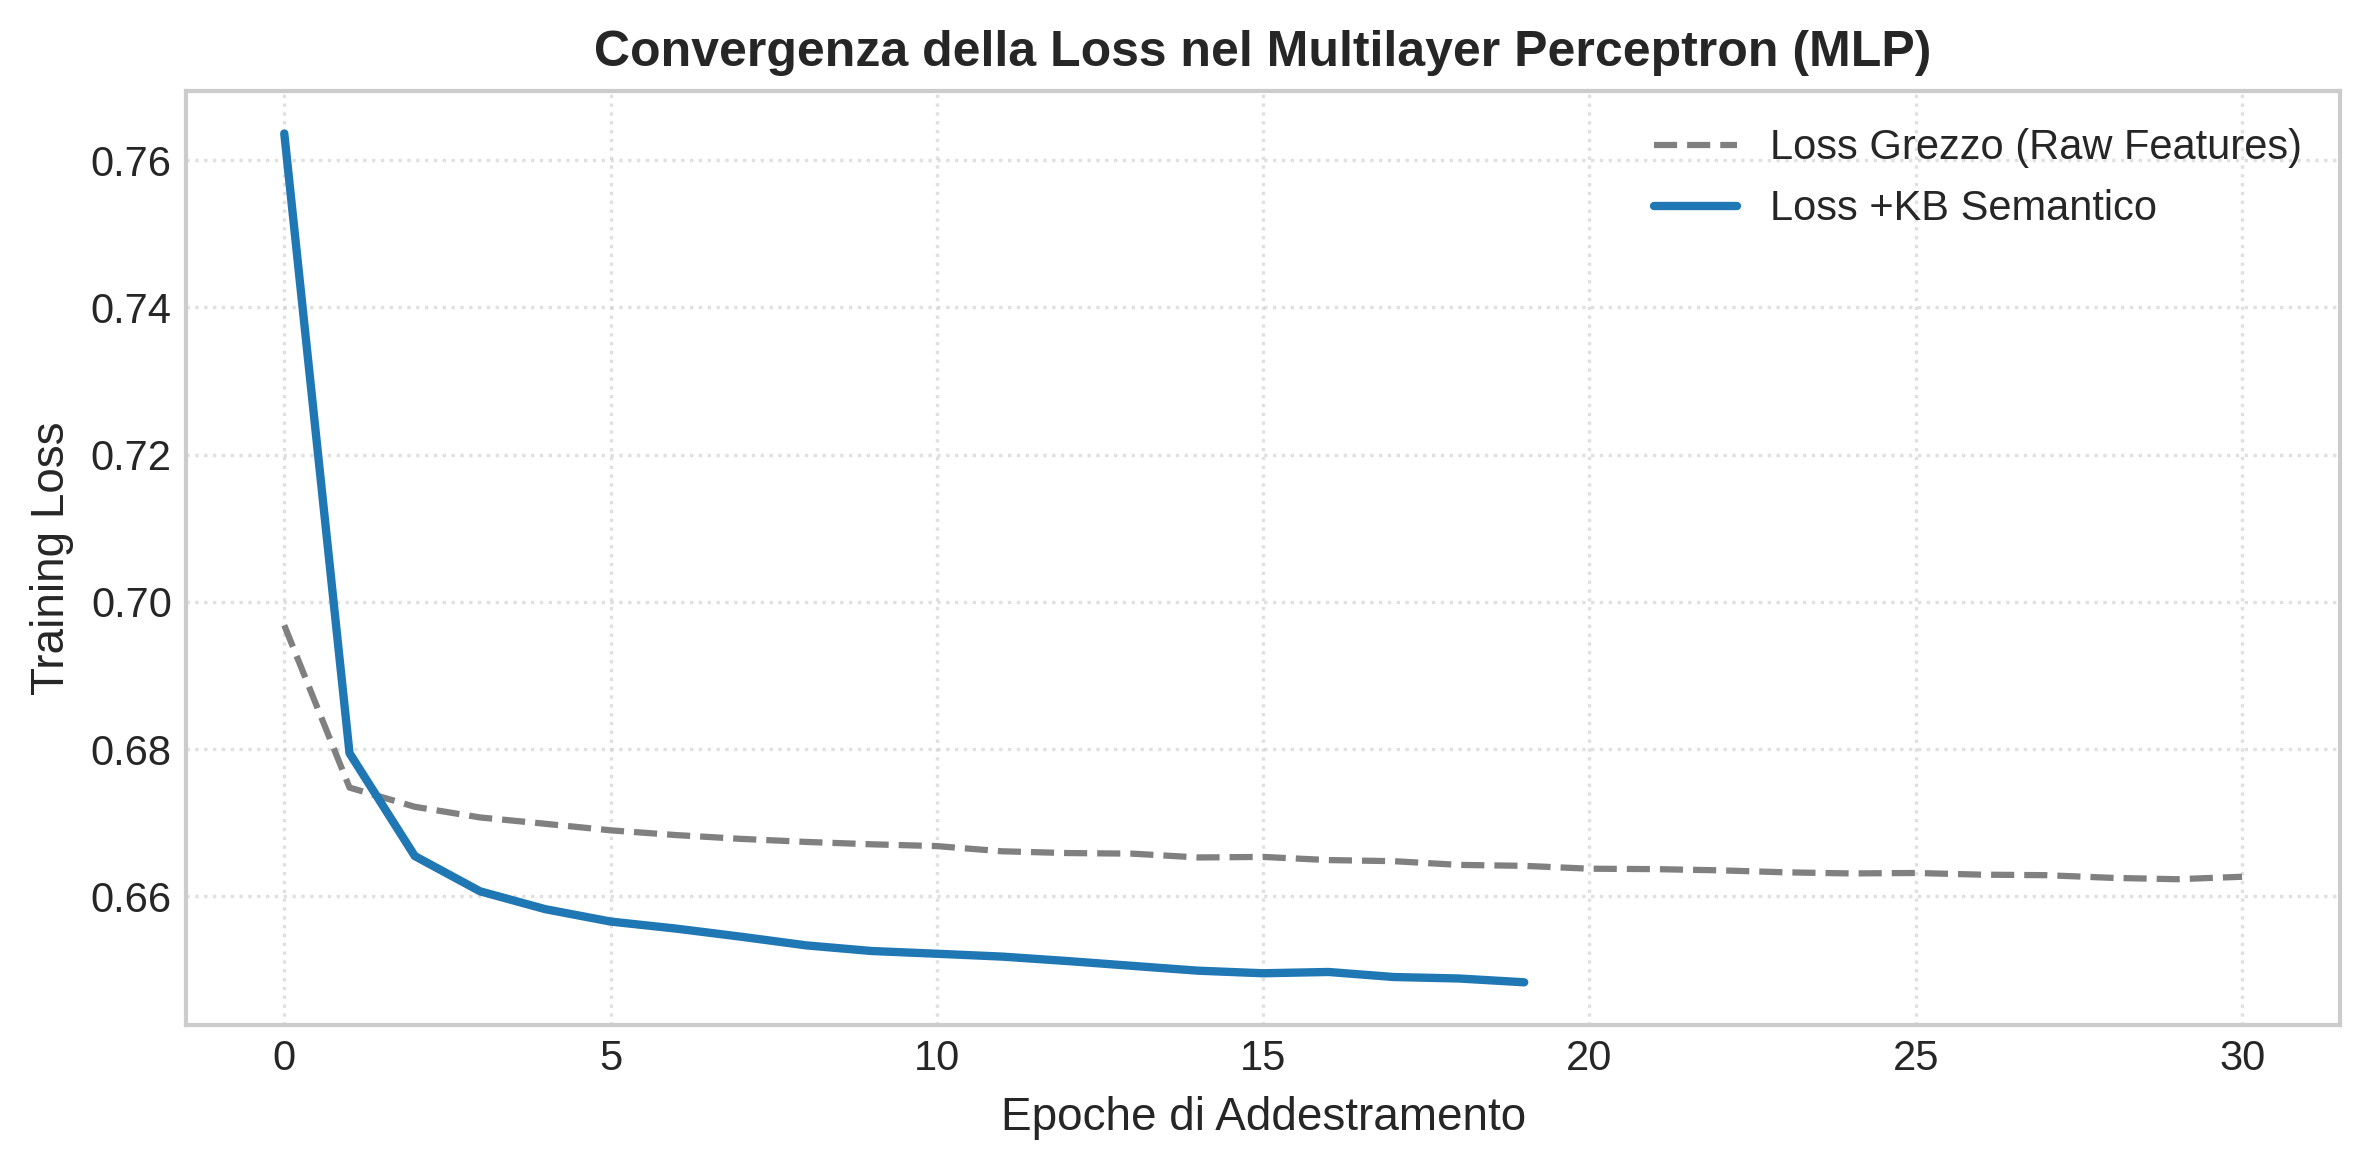

ANALISI DI SENSIBILITÀ DEGLI IPERPARAMETRI: BIAS-VARIANZA E REGOLARIZZAZIONE


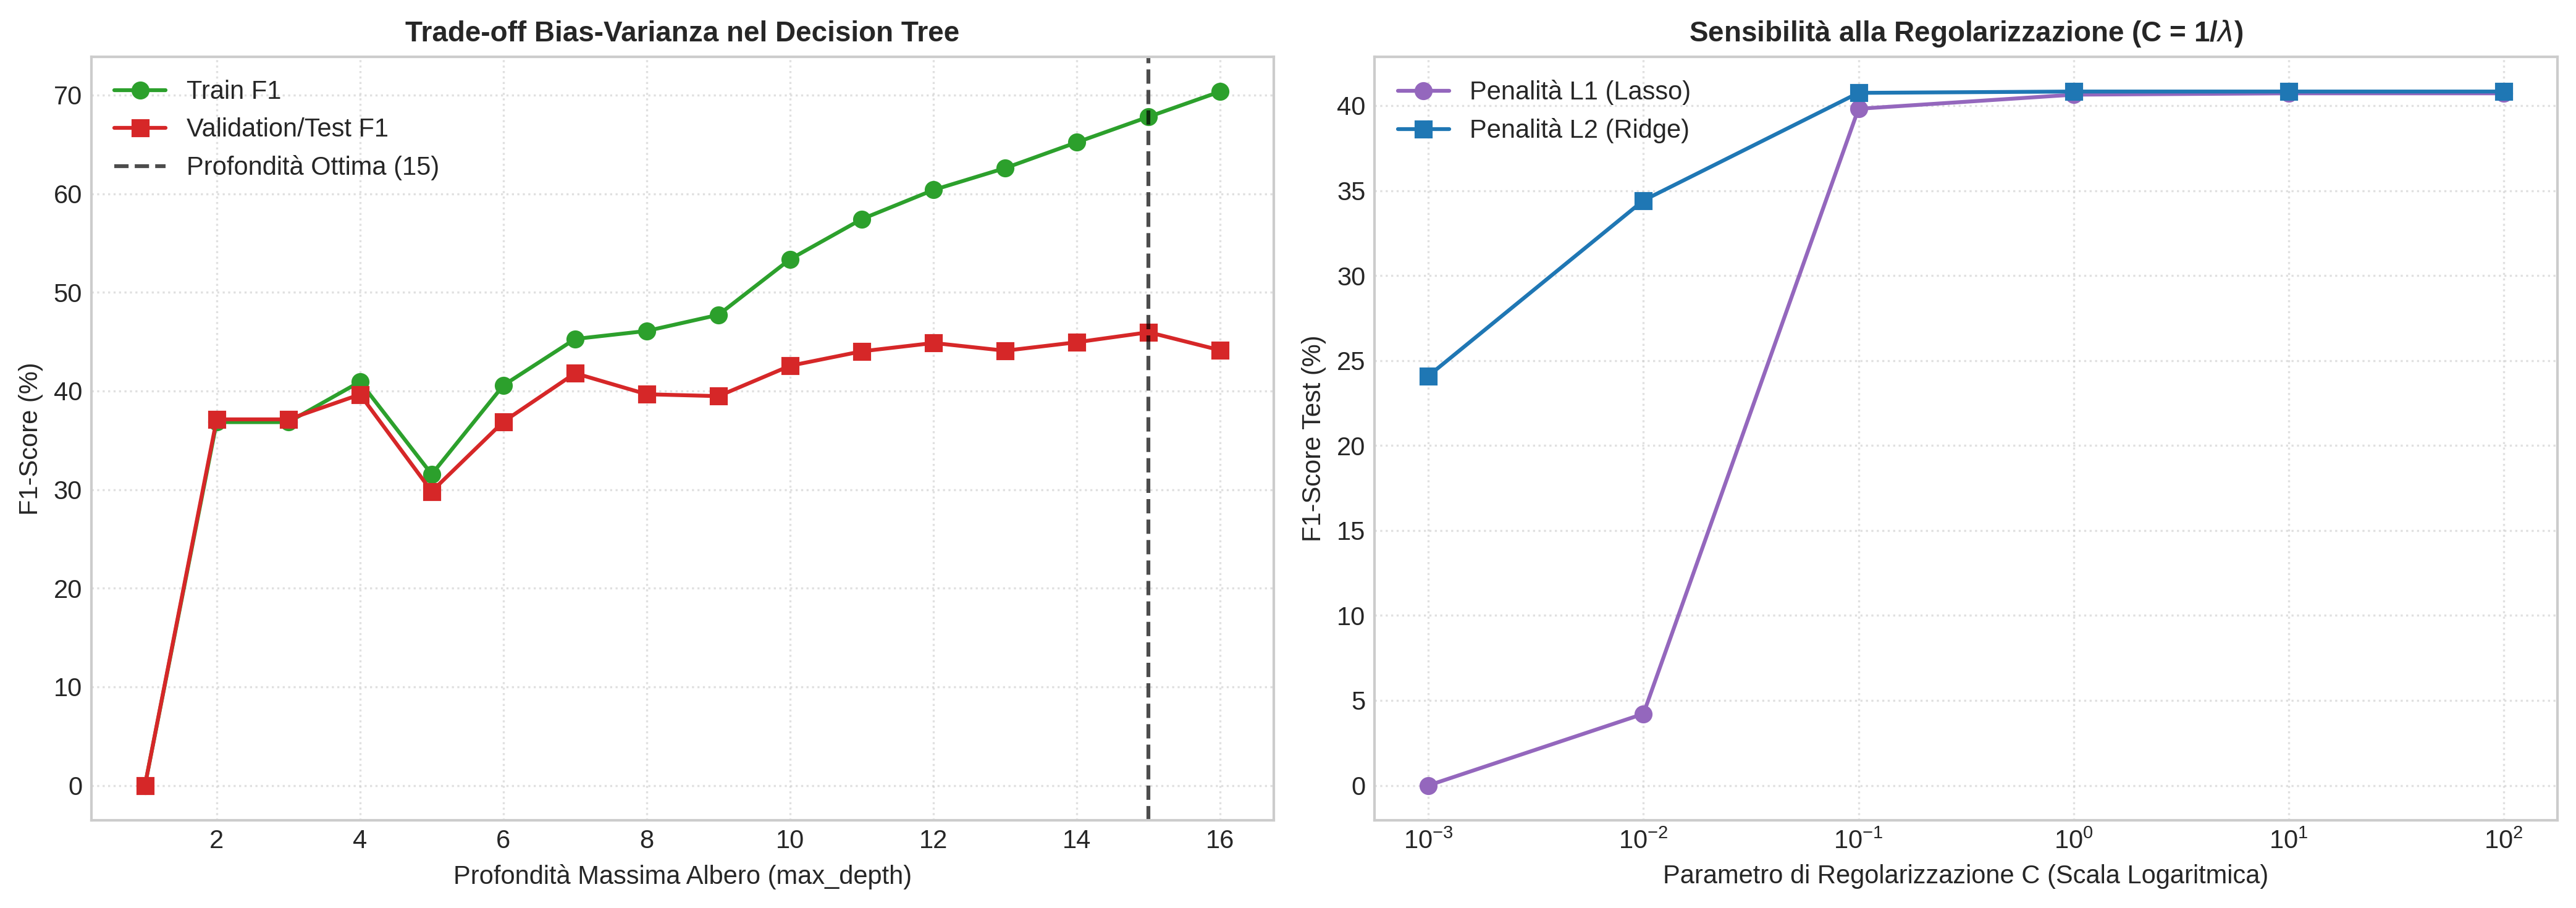

In [10]:
# MULTILAYER PERCEPTRON (MLP)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score

print("ADDESTRAMENTO MODELLO DEEP LEARNING (MLP FEED-FORWARD)")

# Rete con 2 strati nascosti (32, 16 nodi), attivazione ReLU, regolarizzazione L2 (alpha)
mlp_raw = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam',
                        alpha=0.01, max_iter=200, random_state=42, early_stopping=True)
mlp_kb  = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam',
                        alpha=0.01, max_iter=200, random_state=42, early_stopping=True)

# Addestramento su uno split standard per valutare le curve di perdita
mlp_raw.fit(X_raw_train, y_train)
mlp_kb.fit(X_kb_train, y_train)

pred_mlp_raw = mlp_raw.predict(X_raw_test)
pred_mlp_kb  = mlp_kb.predict(X_kb_test)

print(f"MLP (Grezzo) -> F1-Score: {f1_score(y_test, pred_mlp_raw)*100:.2f}%")
print(f"MLP (+KB)     -> F1-Score: {f1_score(y_test, pred_mlp_kb)*100:.2f}%")

# Plot delle curve di perdita (Loss Curve) durante l'addestramento
plt.figure(figsize=(8, 4), dpi=300)
plt.plot(mlp_raw.loss_curve_, label='Loss Grezzo (Raw Features)', color='gray', linestyle='--')
plt.plot(mlp_kb.loss_curve_, label='Loss +KB Semantico', color='#1f77b4', linewidth=2)
plt.title('Convergenza della Loss nel Multilayer Perceptron (MLP)', fontsize=12, fontweight='bold')
plt.xlabel('Epoche di Addestramento', fontsize=11)
plt.ylabel('Training Loss', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('mlp_loss_convergence.png')
plt.show()


# FINE-TUNING E STUDIO DELLA SENSIBILITÀ DEGLI IPERPARAMETRI
print("ANALISI DI SENSIBILITÀ DEGLI IPERPARAMETRI: BIAS-VARIANZA E REGOLARIZZAZIONE")

# 1. Impatto della profondità dell'albero decisionale (max_depth: 1 -> 16)
depths = range(1, 17)
train_scores = []
test_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_kb_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_kb_train)))
    test_scores.append(f1_score(y_test, dt.predict(X_kb_test)))

# 2. Impatto della regolarizzazione L1 vs L2 nella Regressione Logistica
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
l1_scores = []
l2_scores = []

for c in c_values:
    # L1 (Sparsity / Feature Selection implicita)
    lr_l1 = LogisticRegression(penalty='l1', C=c, solver='saga', max_iter=500, random_state=42)
    lr_l1.fit(X_kb_train, y_train)
    l1_scores.append(f1_score(y_test, lr_l1.predict(X_kb_test)))

    # L2 (Ridge)
    lr_l2 = LogisticRegression(penalty='l2', C=c, solver='lbfgs', max_iter=500, random_state=42)
    lr_l2.fit(X_kb_train, y_train)
    l2_scores.append(f1_score(y_test, lr_l2.predict(X_kb_test)))

# Visualizzazione comparativa del Fine-Tuning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Subplot 1: Decision Tree Depth vs F1-Score (Dimostrazione di Overfitting)
ax1.plot(depths, [s * 100 for s in train_scores], 'o-', label='Train F1', color='#2ca02c')
ax1.plot(depths, [s * 100 for s in test_scores], 's-', label='Validation/Test F1', color='#d62728')
ax1.set_title('Trade-off Bias-Varianza nel Decision Tree', fontsize=11, fontweight='bold')
ax1.set_xlabel('Profondità Massima Albero (max_depth)', fontsize=10)
ax1.set_ylabel('F1-Score (%)', fontsize=10)
ax1.axvline(x=depths[np.argmax(test_scores)], color='black', linestyle='--', alpha=0.7,
            label=f'Profondità Ottima ({depths[np.argmax(test_scores)]})')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: L1 vs L2
ax2.semilogx(c_values, [s * 100 for s in l1_scores], 'o-', label='Penalità L1 (Lasso)', color='#9467bd')
ax2.semilogx(c_values, [s * 100 for s in l2_scores], 's-', label='Penalità L2 (Ridge)', color='#1f77b4')
ax2.set_title('Sensibilità alla Regolarizzazione (C = 1/$\lambda$)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Parametro di Regolarizzazione C (Scala Logaritmica)', fontsize=10)
ax2.set_ylabel('F1-Score Test (%)', fontsize=10)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('advanced_finetuning_analysis.png')
plt.show()

In [11]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

# 1. Preparazione DataFrame discretizzato (tutto in formato stringa)
df_bayes = pd.DataFrame({
    'Therapeutic_Area': df['Therapeutic_Area'].astype(str),
    'Drug_Complexity': df['Drug_Complexity'].astype(str),
    'Toxicity_Tier': df['Toxicity_Tier'].astype(str),
    'Clinical_Risk': df['Clinical_Risk'].astype(str),
    'Target_Success': df['Target_Success'].astype(str)
})

# 2. Definizione del DAG Causale
model = DiscreteBayesianNetwork([
    ('Therapeutic_Area', 'Clinical_Risk'),
    ('Drug_Complexity', 'Clinical_Risk'),
    ('Clinical_Risk', 'Target_Success'),
    ('Toxicity_Tier', 'Target_Success')
])

# 3. Fit dei parametri (MLE di default)
try:
    model.fit(df_bayes)
except TypeError:
    from pgmpy.estimators import MaximumLikelihoodEstimator
    model.fit(df_bayes, estimator=MaximumLikelihoodEstimator)

print("Controllo consistenza del modello Bayesiano:", model.check_model())

# 4. Inizializzazione motore di inferenza esatta (Variable Elimination)
infer = VariableElimination(model)

# 5. Simulazione scenari What-If
print("\n" + "="*70)
print("SCENARIO 1: Monoterapia Cardiovascolare a Bassa Tossicità")
print("="*70)
res1 = infer.query(variables=['Target_Success'], evidence={
    'Therapeutic_Area': 'Cardiovascular',
    'Drug_Complexity': 'Mono_Component',
    'Toxicity_Tier': 'Low_Toxicity'
})
print(res1)

print("\n" + "="*70)
print("SCENARIO 2: Politerapia (Multi-Drug) ad Alta Tossicità")
print("="*70)
res2 = infer.query(variables=['Target_Success'], evidence={
    'Drug_Complexity': 'Multi_Component',
    'Toxicity_Tier': 'High_Toxicity'
})
print(res2)

print("\n" + "="*70)
print("SCENARIO 3: Trattamento Oncologico ad Alta Sorveglianza")
print("="*70)
res3 = infer.query(variables=['Target_Success'], evidence={
    'Therapeutic_Area': 'Oncology',
    'Toxicity_Tier': 'High_Toxicity'
})
print(res3)

# 6. Inferenza diagnostica inversa (Explaining Away)
print("DIAGNOSTICA INVERSA: Rischio Clinico dato l'Insuccesso Terapeutico (Target=0)")
res_diag = infer.query(variables=['Clinical_Risk'], evidence={'Target_Success': '0'})
print(res_diag)

Controllo consistenza del modello Bayesiano: True

SCENARIO 1: Monoterapia Cardiovascolare a Bassa Tossicità
+-------------------+-----------------------+
| Target_Success    |   phi(Target_Success) |
+===================+=======================+
| Target_Success(0) |                0.6220 |
+-------------------+-----------------------+
| Target_Success(1) |                0.3780 |
+-------------------+-----------------------+

SCENARIO 2: Politerapia (Multi-Drug) ad Alta Tossicità
+-------------------+-----------------------+
| Target_Success    |   phi(Target_Success) |
+===================+=======================+
| Target_Success(0) |                0.5838 |
+-------------------+-----------------------+
| Target_Success(1) |                0.4162 |
+-------------------+-----------------------+

SCENARIO 3: Trattamento Oncologico ad Alta Sorveglianza
+-------------------+-----------------------+
| Target_Success    |   phi(Target_Success) |
+===================+=====================

In [12]:
# STRUCTURE LEARNING (APPRENDIMENTO STRUTTURALE DEL DAG)
from pgmpy.estimators import HillClimbSearch

print("STRUCTURE LEARNING: APPRENDIMENTO AUTOMATICO DEL DAG TRAMITE HILL-CLIMB SEARCH")

# Hill-Climb sul DataFrame discretizzato
hc = HillClimbSearch(df_bayes)

estimated_model = hc.estimate(scoring_method="bic-d", max_iter=50, show_progress=False)

print("\n[Archi del Grafo appreso automaticamente dai dati]:")
learned_edges = list(estimated_model.edges())
for u, v in learned_edges:
    print(f"  {u}  --->  {v}")
print("\n")

# Confronto con il DAG dell'Esperto di Dominio
expert_edges = set(model.edges())
data_edges = set(learned_edges)

print("CONFRONTO TOPOLOGICO:")
print(f"Archi confermati da entrambi (Esperto & Dati): {expert_edges.intersection(data_edges)}")
print(f"Archi presenti solo nel modello Esperto:       {expert_edges - data_edges}")
print(f"Nuove relazioni latenti scoperte dai dati:     {data_edges - expert_edges}")


STRUCTURE LEARNING: APPRENDIMENTO AUTOMATICO DEL DAG TRAMITE HILL-CLIMB SEARCH

[Archi del Grafo appreso automaticamente dai dati]:
  Therapeutic_Area  --->  Target_Success
  Drug_Complexity  --->  Clinical_Risk
  Drug_Complexity  --->  Therapeutic_Area
  Toxicity_Tier  --->  Clinical_Risk
  Toxicity_Tier  --->  Therapeutic_Area
  Toxicity_Tier  --->  Drug_Complexity
  Clinical_Risk  --->  Therapeutic_Area


CONFRONTO TOPOLOGICO:
Archi confermati da entrambi (Esperto & Dati): {('Drug_Complexity', 'Clinical_Risk')}
Archi presenti solo nel modello Esperto:       {('Toxicity_Tier', 'Target_Success'), ('Clinical_Risk', 'Target_Success'), ('Therapeutic_Area', 'Clinical_Risk')}
Nuove relazioni latenti scoperte dai dati:     {('Therapeutic_Area', 'Target_Success'), ('Clinical_Risk', 'Therapeutic_Area'), ('Toxicity_Tier', 'Therapeutic_Area'), ('Drug_Complexity', 'Therapeutic_Area'), ('Toxicity_Tier', 'Drug_Complexity'), ('Toxicity_Tier', 'Clinical_Risk')}
